In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df_multiSubject_binary = pd.read_csv('experiments/experiment2/results/data/multiSubject_binary.csv')
df_multiSubject_discrete = pd.read_csv('experiments/experiment2/results/data/multiSubject_discrete.csv')
df_finetuning_binary = pd.read_csv('experiments/experiment2/results/data/finetuning_binary.csv')
df_finetuning_discrete = pd.read_csv('experiments/experiment2/results/data/finetuning_discrete.csv')
df_singlesubject_binary = pd.read_csv('experiments/experiment1/results/data/singleSubject_binary.csv')
df_singlesubject_discrete = pd.read_csv('experiments/experiment1/results/data/singleSubject_discrete.csv')
df_nasatlx = pd.read_csv("experiments/NASATLX_Averages.csv")

def add_condition_names(df):
    condition_map = {
        "['FW']": ("Flappy Passive", "Flappy", "Passive"),
        "['LW']": ("Lunar Passive", "Lunar", "Passive"),
        "['FP']": ("Flappy Active", "Flappy", "Active"),
        "['LP']": ("Lunar Active", "Lunar", "Active"),
        "['RP']": ("Robot Active", "Robot", "Active"),
        "['RW']": ("Robot Passive", "Robot", "Passive"),
        "['FW', 'LW', 'RW', 'FP', 'LP', 'RP']": ("All Conditions", None, None),
        "['FW', 'LW', 'RW']": ("All Passive", None, "Passive"),
        "['FP', 'LP', 'RP']": ("All Active", None, "Active")
    }

    df["TrainParticipants"] = df["TrainParticipants"].apply(lambda x: eval(x))
    df["TestParticipants"] = df["TestParticipants"].apply(lambda x: eval(x))
    df["TrainConditions"] = df["TrainConditions"].apply(lambda x: eval(x))
    df["TestConditions"] = df["TestConditions"].apply(lambda x: eval(x))

    conditions, games, tasks = [], [], []
    for condition in df["TrainConditions"]:
        condition_str = str(condition)
        if condition_str in condition_map:
            cond, game, task = condition_map[condition_str]
            conditions.append(cond)
            games.append(game)
            tasks.append(task)
        else:
            conditions.append(condition_str)
            games.append(None)
            tasks.append(None)

    df["Conditions"] = conditions
    df["Game"] = games
    df["Task"] = tasks

    return df

df_multiSubject_binary = add_condition_names(df_multiSubject_binary)
df_multiSubject_discrete = add_condition_names(df_multiSubject_discrete)
df_singleSubject_binary = add_condition_names(df_singlesubject_binary)
df_singleSubject_discrete = add_condition_names(df_singlesubject_discrete)
df_finetuning_binary = add_condition_names(df_finetuning_binary)
df_finetuning_discrete = add_condition_names(df_finetuning_discrete)


### NASA TLX Scores

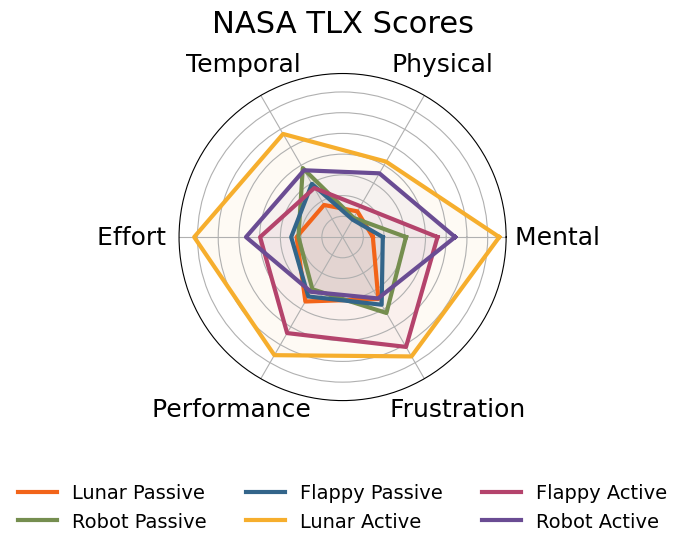

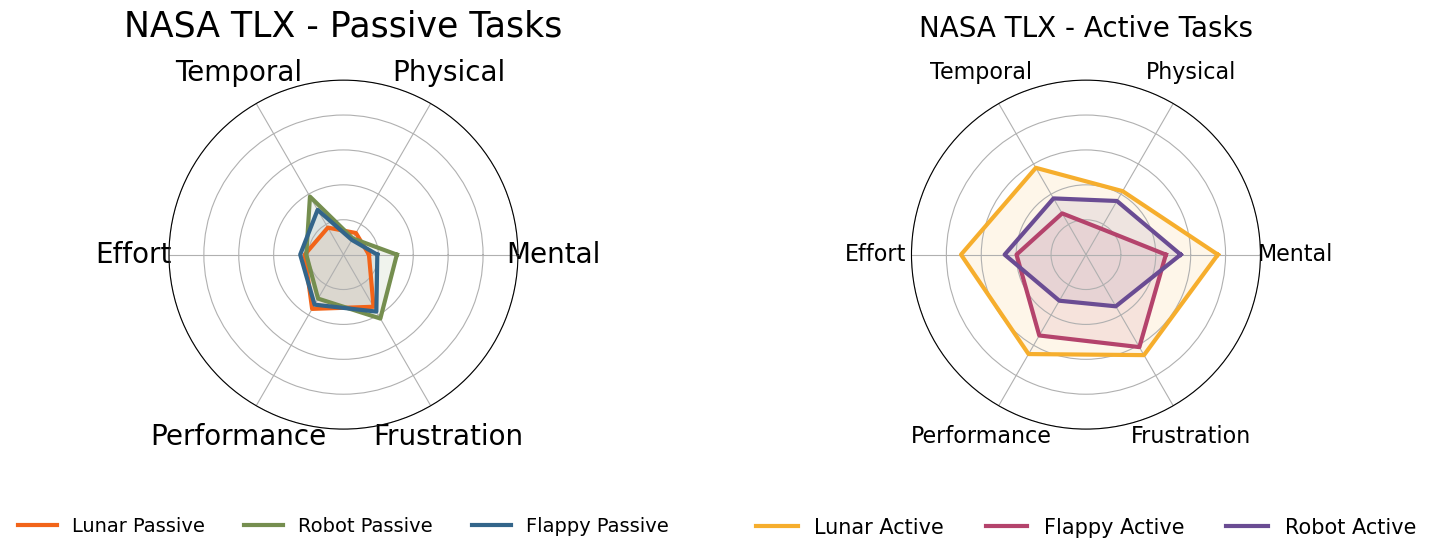

In [3]:
num_vars=6
palette2 = ["#f26419", "#758e4f", "#33658a", "#f6ae2d", "#b4436c", "#6a4c93"]


categories = ["Mental", "Physical", "Temporal", "Effort", "Performance", "Frustration"]
categories2 = ["    Mental", "Physical", "Temporal", "Effort   ", "Performance   ", "    Frustration"]

# Compute angle for each category
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Initialize the radar chart
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

# Plot each condition
for i, row in df_nasatlx.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row['Unnamed: 0'], color=palette2[i % len(palette2)], linewidth=3)
    ax.fill(angles, values, color=palette2[i % len(palette2)], alpha=0.05)

# Customize the plot
ax.set_title('NASA TLX Scores', size=22, color='black', y=1.1)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories2, size=18, color='black')
ax.tick_params(axis='x', which='major', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=14, ncol=3, frameon=False)

# Adjust the layout to make sure everything fits well
plt.tight_layout()
plt.show()
# Split the data into passive and active tasks
df_nasatlx_passive = df_nasatlx[df_nasatlx['Unnamed: 0'].str.contains('Passive')]
df_nasatlx_active = df_nasatlx[df_nasatlx['Unnamed: 0'].str.contains('Active')]

# Initialize the radar chart for passive and active tasks
fig, axes = plt.subplots(1, 2, figsize=(15, 6), subplot_kw=dict(polar=True))

# Plot each condition for passive tasks
for i, row in df_nasatlx_passive.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    axes[0].plot(angles, values, label=row['Unnamed: 0'], color=palette2[i % len(palette2)], linewidth=3)
    axes[0].fill(angles, values, color=palette2[i % len(palette2)], alpha=0.1)

# Customize the plot for passive tasks
axes[0].set_title('NASA TLX - Passive Tasks', size=25, color='black', y=1.1)
axes[0].set_yticklabels([])
axes[0].set_xticks(angles[:-1])
axes[0].set_xticklabels(categories, size=20, color='black')
axes[0].tick_params(axis='x', which='major', pad=15)
axes[0].set_ylim(0, 100)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=14, ncol=3, frameon=False)

# Plot each condition for active tasks
for i, row in df_nasatlx_active.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    axes[1].plot(angles, values, label=row['Unnamed: 0'], color=palette2[i % len(palette2)], linewidth=3)
    axes[1].fill(angles, values, color=palette2[i % len(palette2)], alpha=0.1)

# Customize the plot for active tasks
axes[1].set_title('NASA TLX - Active Tasks', size=20, color='black', y=1.1)
axes[1].set_yticklabels([])
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(categories, size=16, color='black')
axes[1].tick_params(axis='x', which='major', pad=15)
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=15, ncol=3, frameon=False)

# Adjust the layout to make sure everything fits well
plt.tight_layout()
plt.show()

KeyError: "The following 'value_vars' are not present in the DataFrame: ['Mental Demand', 'Physical Demand', 'Temporal Demand']"

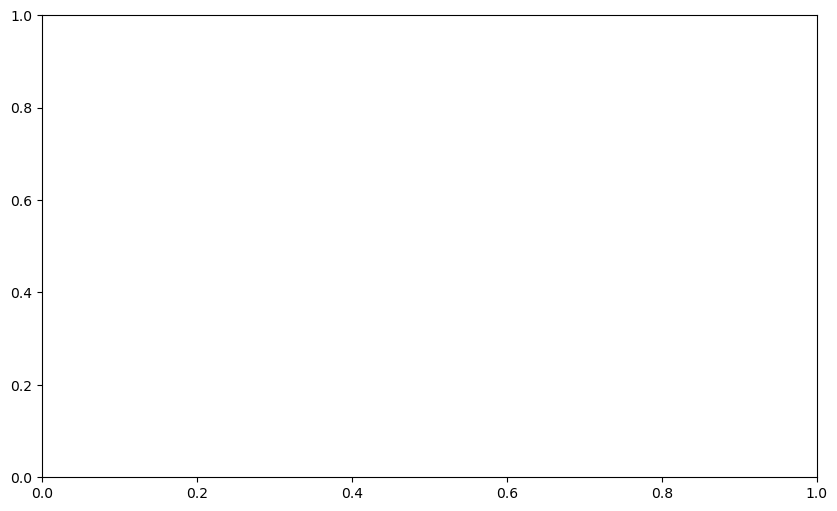

In [4]:
df_nasatlx
# Create a figure to show the NASA TLX data for each condition
fig, ax = plt.subplots(figsize=(10, 6))

# Melt the dataframe to long format for easier plotting
df_nasatlx_long = pd.melt(df_nasatlx, id_vars=['Unnamed: 0'], value_vars=['Mental Demand', 'Physical Demand', 'Temporal Demand', 'Effort', 'Performance', 'Frustration'],
                          var_name='Metric', value_name='Score')
palette2 = ["#f07167", "#fed9b7", "#f4d35e", "#81b29a", "#0081a7", "#6247aa"]

# Plot the data
sns.barplot(data=df_nasatlx_long, x='Metric', y='Score', hue='Unnamed: 0', palette=palette2, ax=ax)

# Customize the plot
ax.set_title('NASA TLX Scores per Condition', fontsize=20)
ax.set_xlabel('Condition', fontsize=16)
ax.set_ylabel('Score', fontsize=16)
ax.tick_params(axis='x', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(title='Metric', title_fontsize='14', fontsize='12')

plt.tight_layout()
plt.show()

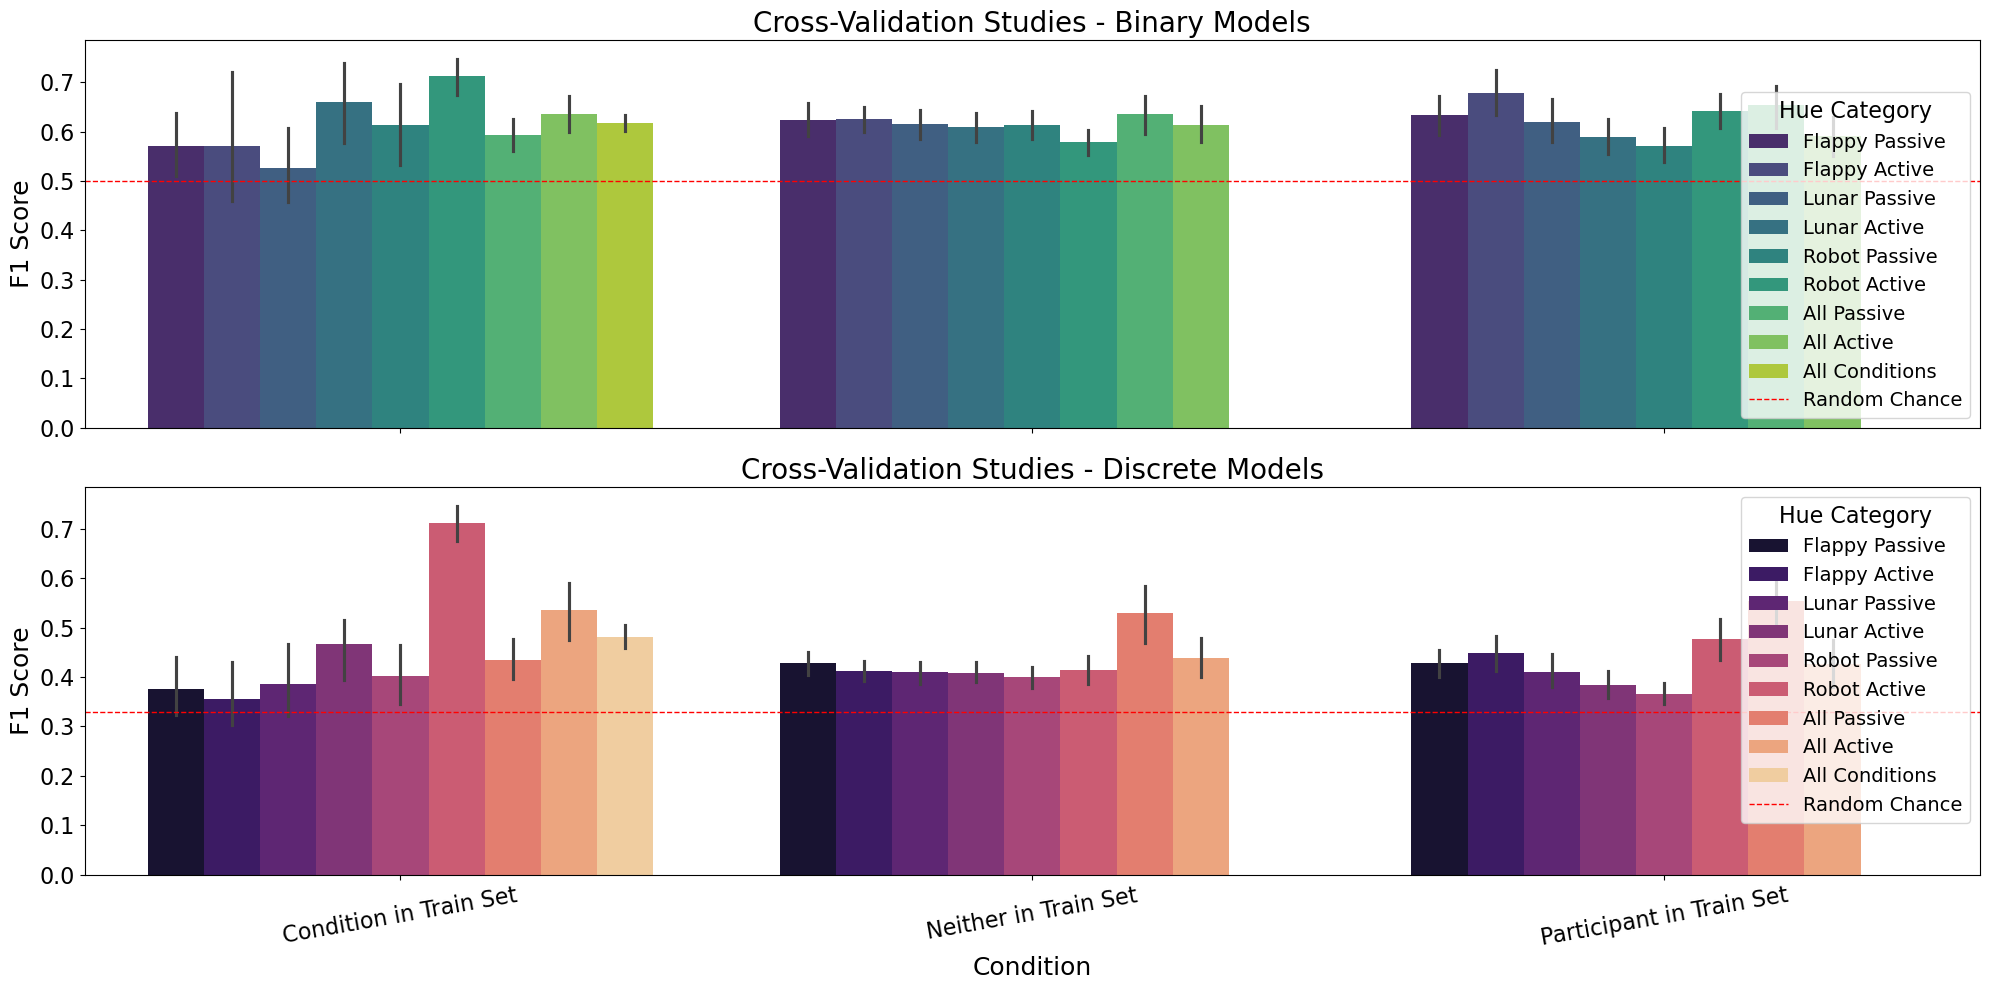

In [5]:
# Add a new column to indicate the hue category
def get_hue_category(row):
    if row['TestConditions'][0] in row['TrainConditions'] and row['TestParticipants'][0] not in row['TrainParticipants'] and row['TestParticipants'] != row['TrainParticipants']:
        return 'Condition in Train Set'
    elif row['TestConditions'][0] not in row['TrainConditions'] and row['TestParticipants'][0] in row['TrainParticipants'] and row['TestParticipants'] != row['TrainParticipants']:
        return 'Participant in Train Set'
    else:
        return "Neither in Train Set"

df_finetuning_binary['HueCategory'] = df_finetuning_binary.apply(get_hue_category, axis=1)
df_finetuning_discrete['HueCategory'] = df_finetuning_discrete.apply(get_hue_category, axis=1)

df_binary = df_finetuning_binary[df_finetuning_binary["Classifier"]=="MLP"]
df_discrete = df_finetuning_discrete[df_finetuning_discrete["Classifier"]== "MLP"]

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier', 'HueCategory'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier', 'HueCategory'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='HueCategory', y='F1 Score', hue='Conditions', palette='viridis', ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Cross-Validation Studies - Binary Models', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=10, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Hue Category', title_fontsize='16', fontsize='14')

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='HueCategory', y='F1 Score', hue='Conditions', palette='magma', ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Cross-Validation Studies - Discrete Models', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=10, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Hue Category', title_fontsize='16', fontsize='14')

plt.tight_layout()
plt.show()

### Single Subject Macro F1 Cross Studies

/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/2006770744.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary['HueCategory'] = binary.apply(get_hue_category, axis=1)
/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/2006770744.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  discrete['HueCategory'] = discrete.apply(get_hue_category, axis=1)
/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/2006770744.py:41: UserWarning: The palette list has more va

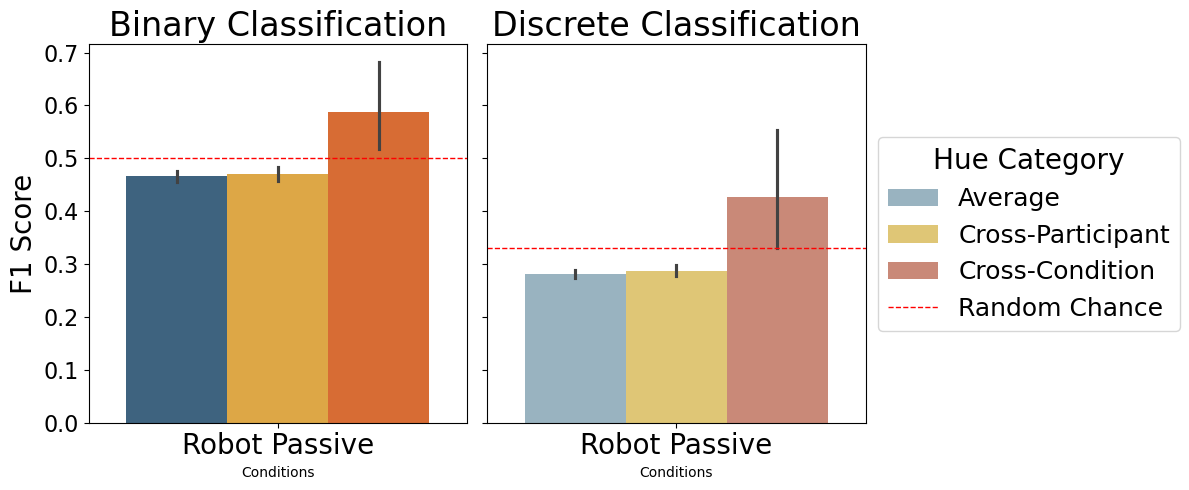

In [6]:
# Filter the data to include only 'Robot Passive' condition
binary = df_multiSubject_binary[(df_multiSubject_binary['TestParticipants'] != df_multiSubject_binary['TrainParticipants']) & (df_multiSubject_binary['Conditions'] == 'Robot Passive')]
discrete = df_multiSubject_discrete[(df_multiSubject_discrete['TestParticipants'] != df_multiSubject_discrete['TrainParticipants']) & (df_multiSubject_discrete['Conditions'] == 'Robot Passive')]

def get_hue_category(row):
    if row['TestConditions'][0] in row['TrainConditions'] and row['TestParticipants'][0] not in row['TrainParticipants'] and row['TestParticipants'] != row['TrainParticipants']:
        return 'Cross-Condition'
    elif row['TestConditions'][0] not in row['TrainConditions'] and row['TestParticipants'][0] in row['TrainParticipants'] and row['TestParticipants'] != row['TrainParticipants']:
        return 'Cross-Participant'
    elif (row['TestParticipants'] != row['TrainParticipants']) and (row['TestConditions'] != row['TrainConditions']):
        return "Average"
    else: 
        return "Cross-Neither"

palette = ["#33658a", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#f0cf65", "#d7816a", "#bd4f6c"]

binary['HueCategory'] = binary.apply(get_hue_category, axis=1)
discrete['HueCategory'] = discrete.apply(get_hue_category, axis=1)

df_binary = binary[(binary["Classifier"] == "MLP") & (binary["Conditions"]=="Robot Passive")]
df_discrete = discrete[(discrete["Classifier"] == "MLP") & (discrete["Conditions"]=="Robot Passive")]

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier', 'HueCategory'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier', 'HueCategory'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')

# Forcibly set the value of "Robot Active Cross-Condition" bar to 0.33
df_long_discrete.loc[(df_long_discrete['Conditions'] == 'Robot Active') & (df_long_discrete['HueCategory'] == 'Cross-Condition'), 'F1 Score'] = 0.33

# Remove "All Conditions"
df_long_binary = df_long_binary[df_long_binary['Conditions'] != 'All Conditions']
df_long_discrete = df_long_discrete[df_long_discrete['Conditions'] != 'All Conditions']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='HueCategory', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Classification', fontsize=24)
# axes[0].set_xlabel('Condition', fontsize=20)
axes[0].set_ylabel('F1 Score', fontsize=20)
axes[0].tick_params(axis='x', rotation=0, labelsize=20)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend_.remove()

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='HueCategory', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete Classification', fontsize=24)
# axes[1].set_xlabel('Condition', fontsize=20)
axes[1].set_ylabel('F1 Score', fontsize=20)
axes[1].tick_params(axis='x', rotation=0, labelsize=20)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Hue Category', title_fontsize='20', fontsize='18', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


### Multi Subject Macro F1 Across Conditions

/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/3133935732.py:20: UserWarning: 
The palette list has fewer values (5) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_long_binary, x='Classifier', y='F1 Score', hue='Conditions', palette=palette, ax=axes[0])
/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/3133935732.py:30: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_long_discrete, x='Classifier', y='F1 Score', hue='Conditions', palette=palette2, ax=axes[1])


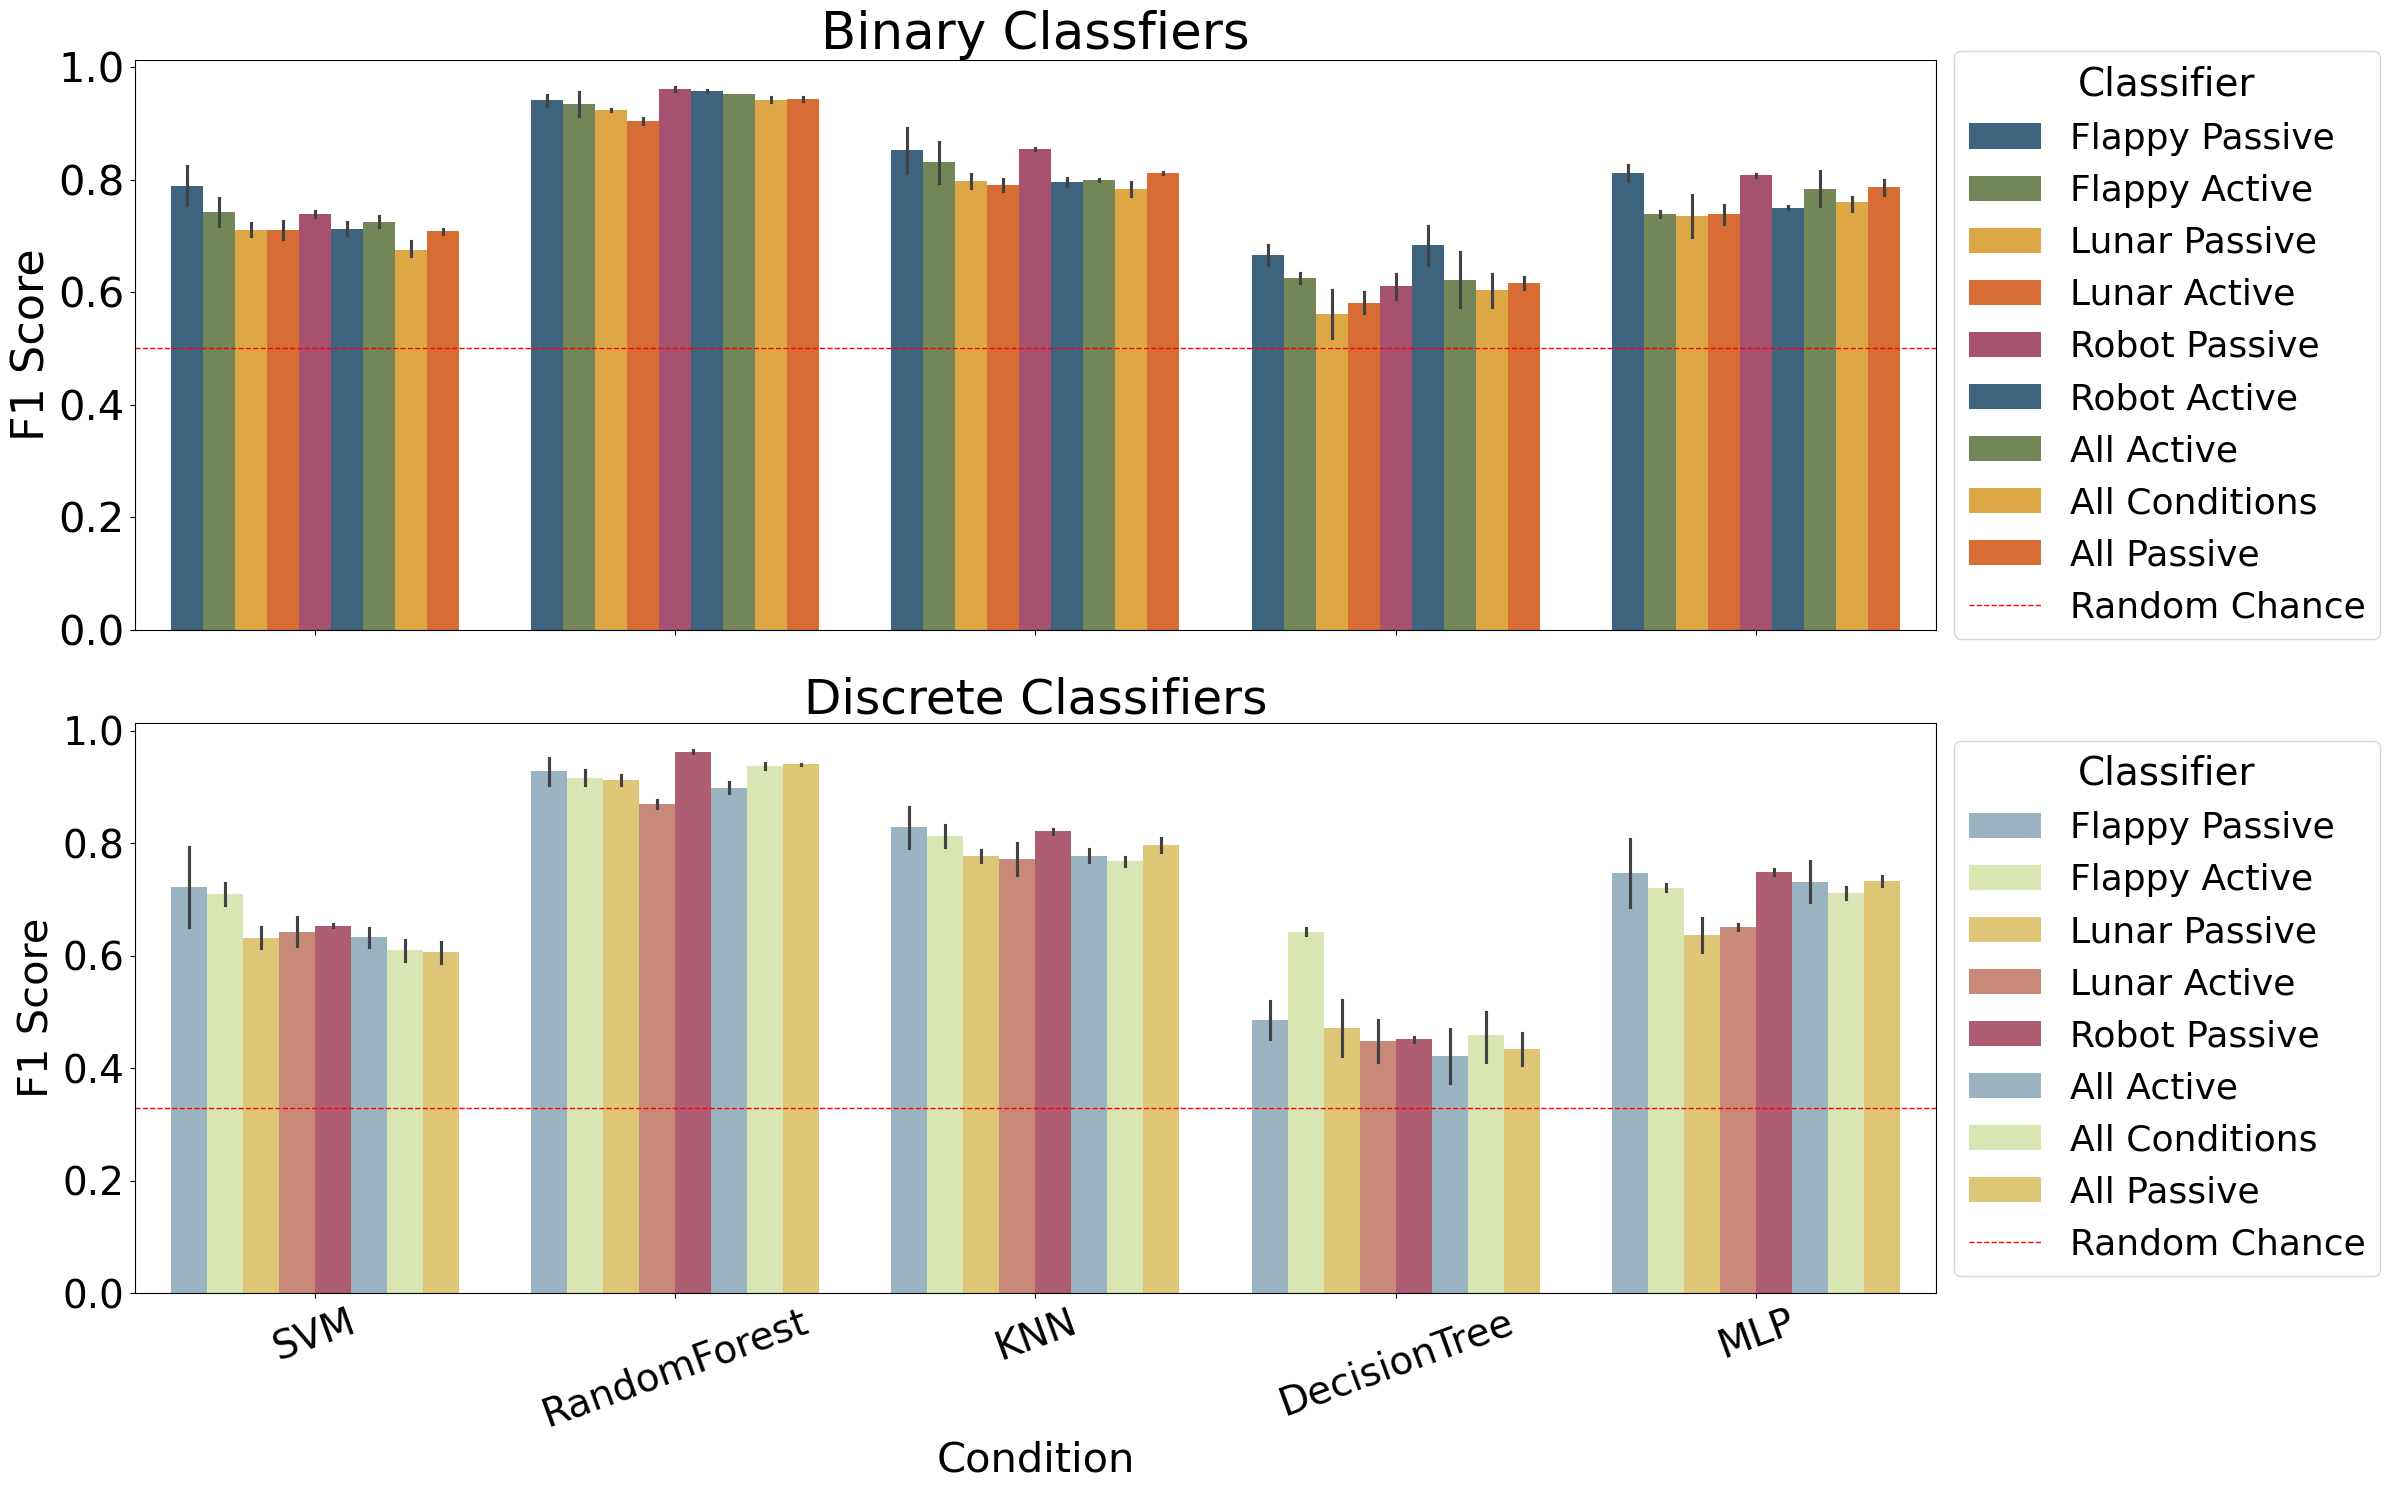

In [7]:
# Filter the data
df_binary = df_multiSubject_binary[df_multiSubject_binary["TestParticipants"] == df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_multiSubject_discrete[df_multiSubject_discrete["TestParticipants"] == df_multiSubject_discrete["TrainParticipants"]]

# Exclude "Robot Active" from the discrete data
df_discrete = df_discrete[df_discrete['Conditions'] != 'Robot Active']

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(24, 15), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Classifier', y='F1 Score', hue='Conditions', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Classfiers', fontsize=37)
axes[0].set_xlabel('Condition', fontsize=32)
axes[0].set_ylabel('F1 Score', fontsize=32)
axes[0].tick_params(axis='x', rotation=20, labelsize=30)
axes[0].tick_params(axis='y', labelsize=30)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Classifier', y='F1 Score', hue='Conditions', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete Classifiers', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


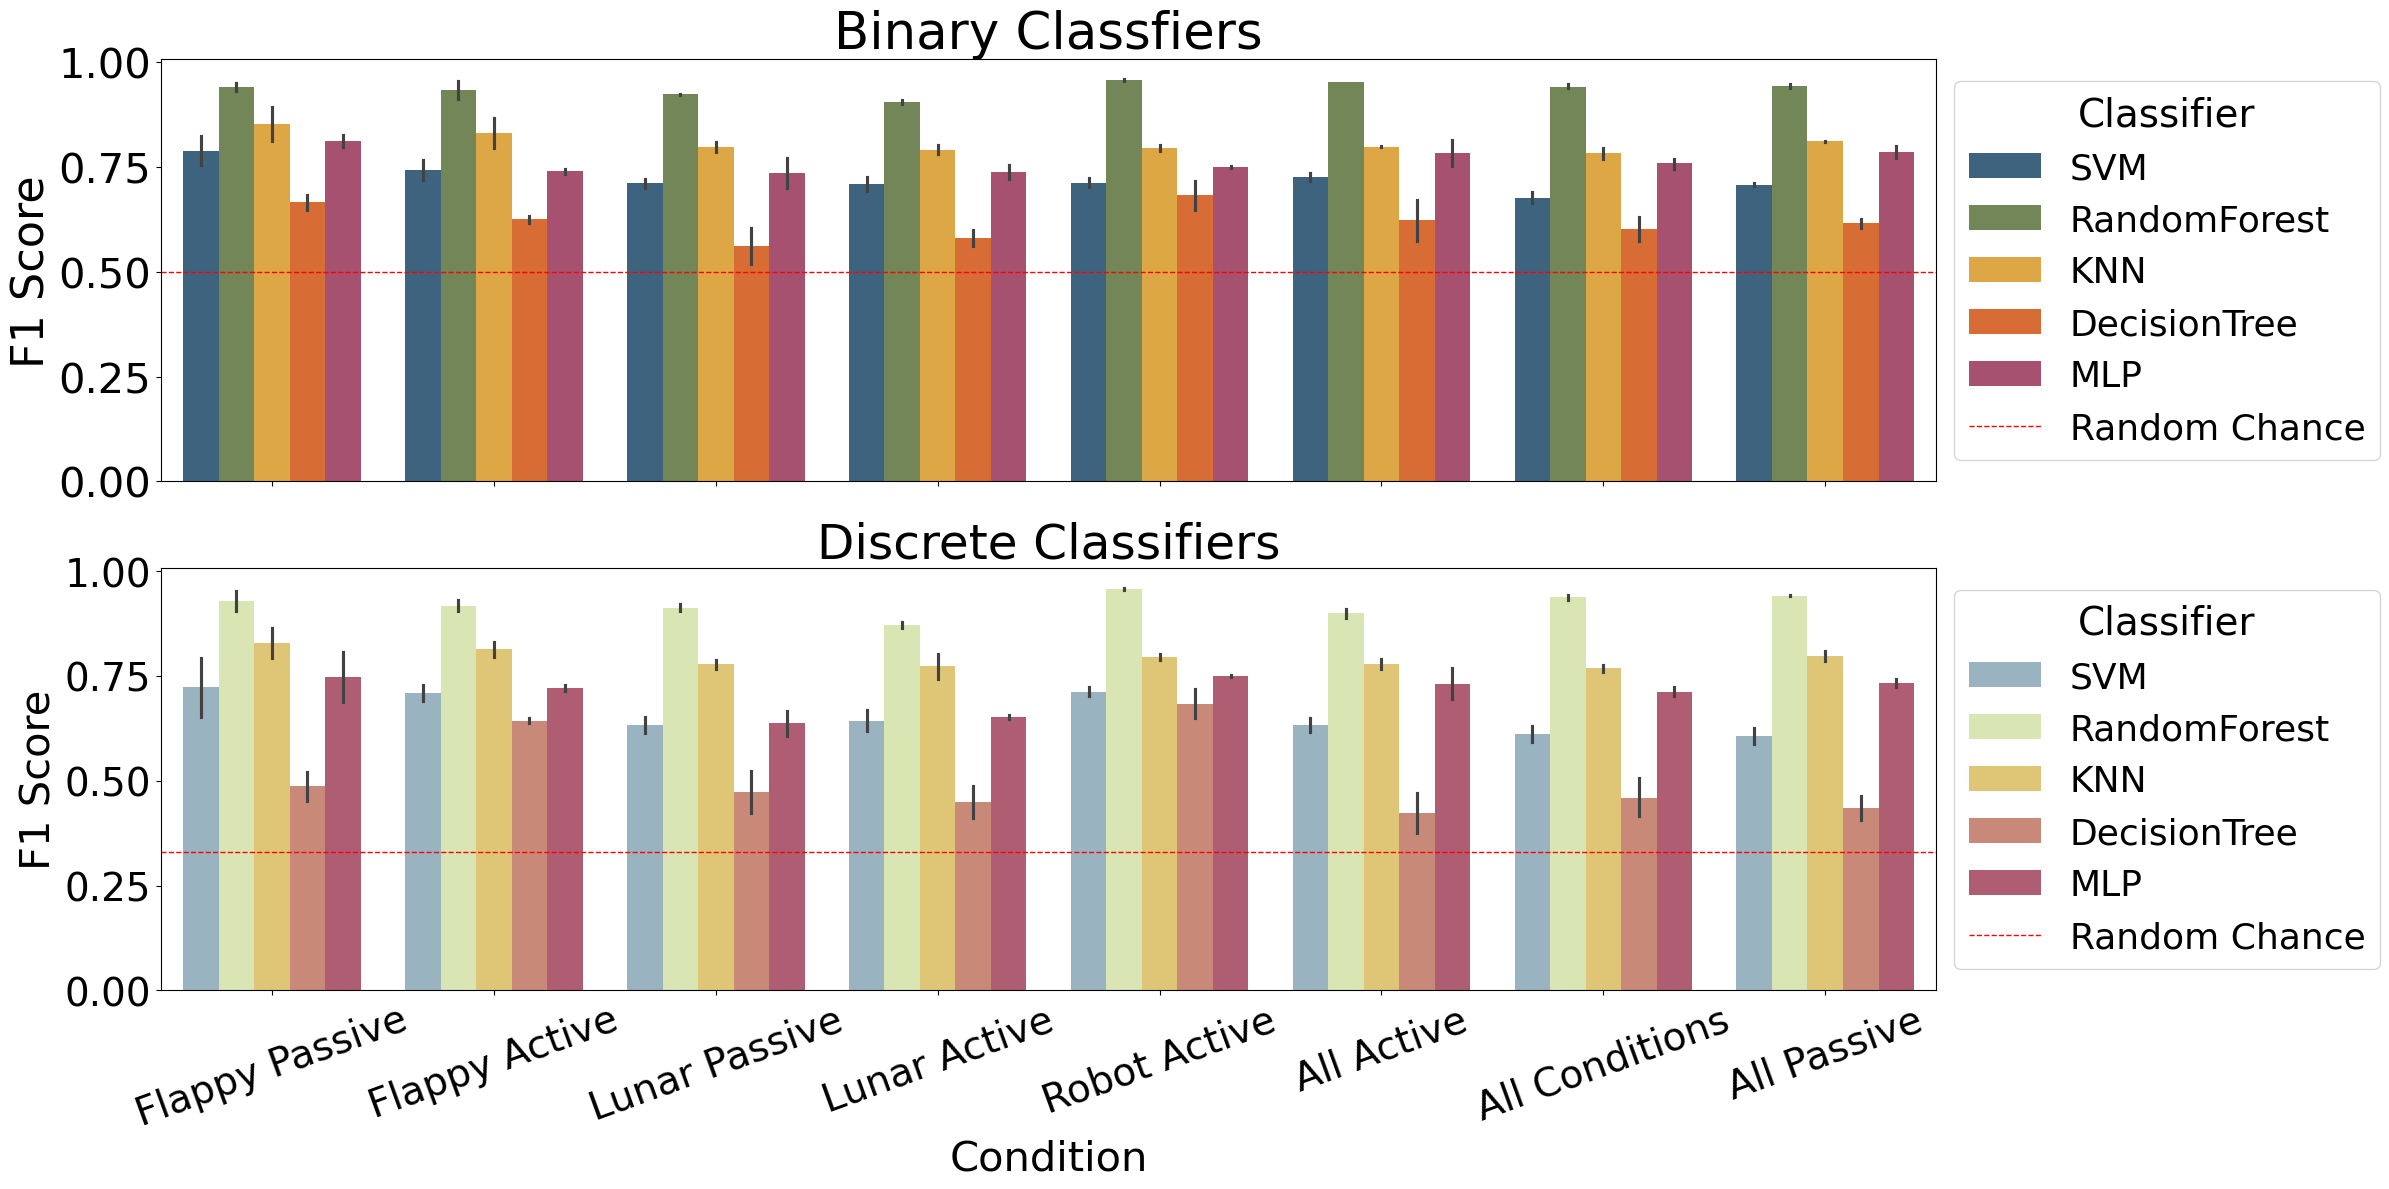

In [15]:
# Filter the data
df_binary = df_multiSubject_binary[df_multiSubject_binary["TestParticipants"] == df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_multiSubject_discrete[df_multiSubject_discrete["TestParticipants"] == df_multiSubject_discrete["TrainParticipants"]]

# Exclude "Robot Active" from the discrete data
df_discrete = df_discrete[(df_discrete['Conditions'] != 'Robot Passive')]
df_binary = df_binary[(df_binary['Conditions'] != 'Robot Passive')]

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(24, 12), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Classfiers', fontsize=37)
axes[0].set_xlabel('Condition', fontsize=32)
axes[0].set_ylabel('F1 Score', fontsize=32)
axes[0].tick_params(axis='x', rotation=20, labelsize=30)
axes[0].tick_params(axis='y', labelsize=30)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete Classifiers', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


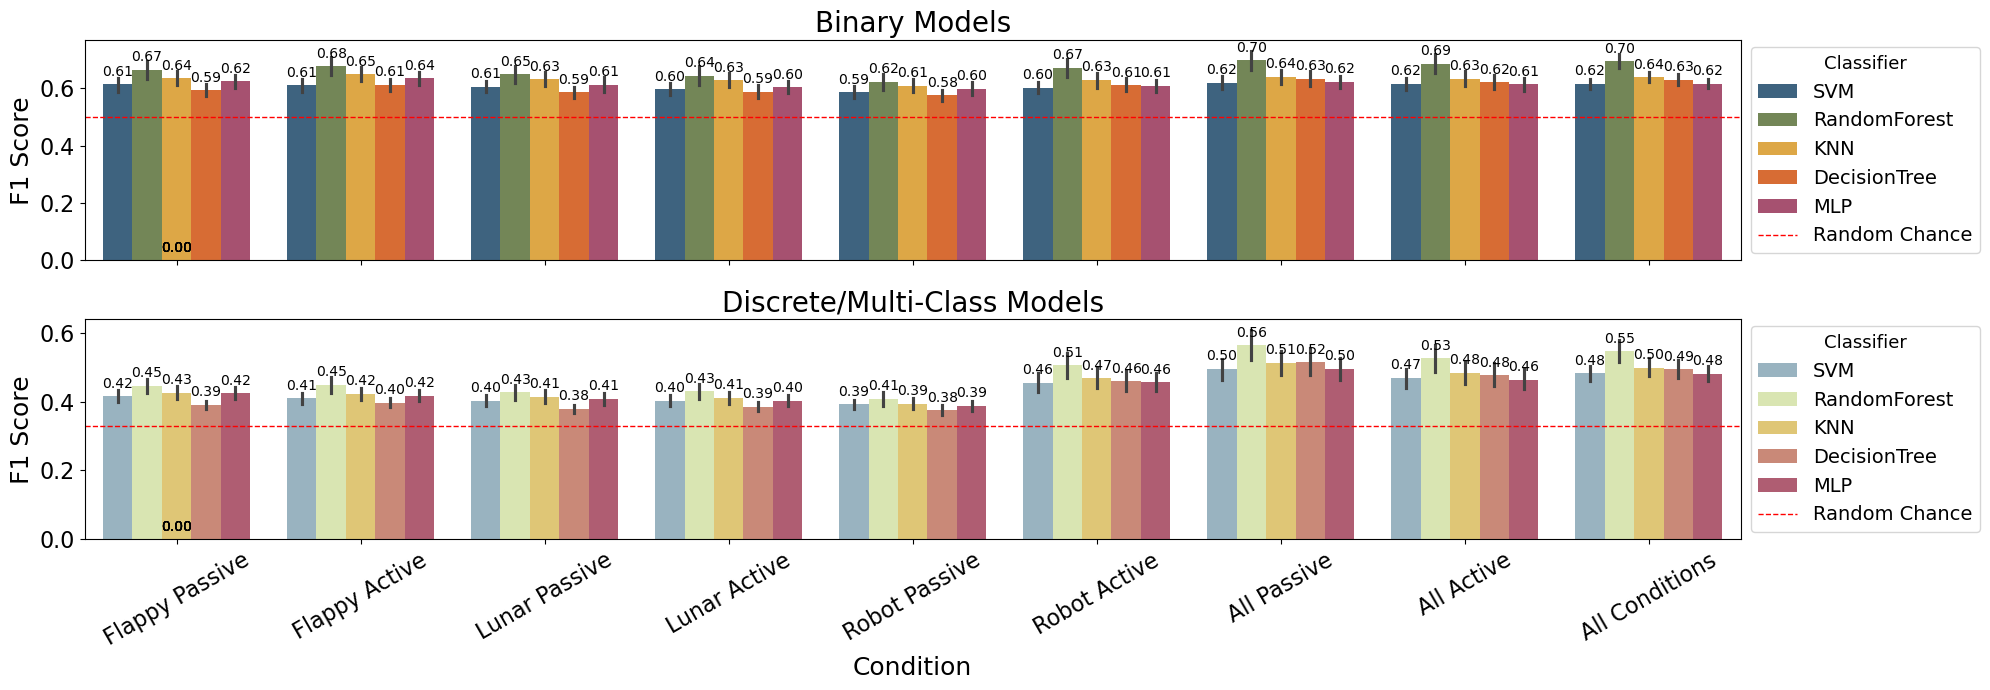

In [9]:
# Filter the data
df_binary = df_finetuning_binary#[df_finetuning_binary["TestParticipants"] == df_finetuning_binary["TrainParticipants"]]
df_discrete = df_finetuning_discrete#[df_finetuning_discrete["TestParticipants"] == df_finetuning_discrete["TrainParticipants"]]

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Models', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=30, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

# Annotate each bar with its height
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete/Multi-Class Models', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=30, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

# Annotate each bar with its height
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

plt.tight_layout()
plt.show()


### Single Subject Macro F1 Across Conditions

/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/1702430573.py:20: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/1702430573.py:38: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])


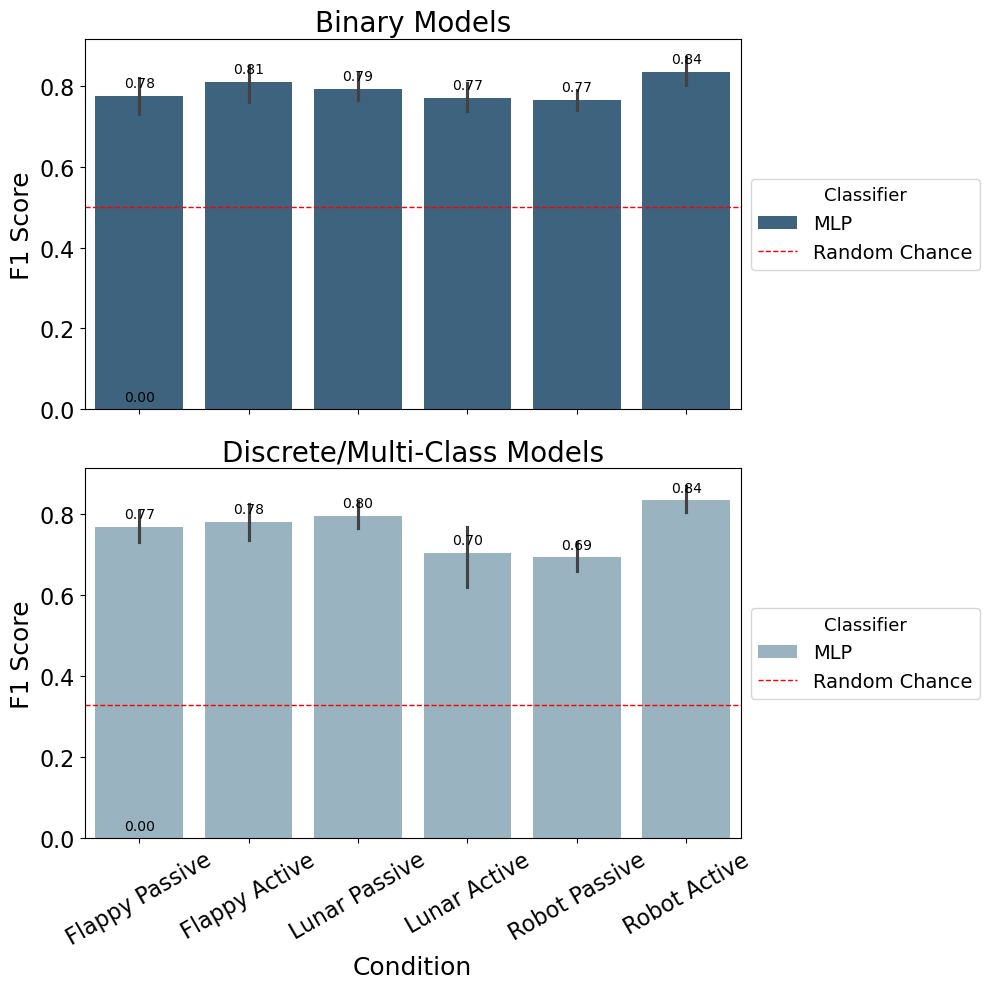

In [10]:
# Filter the data
df_binary = df_singleSubject_binary[(df_singleSubject_binary["TestParticipants"] == df_singleSubject_binary["TrainParticipants"]) & (df_singleSubject_binary["TestConditions"].apply(lambda x: x[0]) == df_singleSubject_binary["TrainConditions"].apply(lambda x: x[0]))]
df_discrete = df_singleSubject_discrete[(df_singleSubject_discrete["TestParticipants"] == df_singleSubject_discrete["TrainParticipants"]) & (df_singleSubject_discrete["TestConditions"].apply(lambda x: x[0]) == df_singleSubject_discrete["TrainConditions"].apply(lambda x: x[0]))]

df_binary = df_binary[df_binary["Classifier"]=="MLP"]
df_discrete = df_discrete[df_discrete["Classifier"]=="MLP"]

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Models', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=30, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

# Annotate each bar with its height
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete/Multi-Class Models', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=30, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

# Annotate each bar with its height
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

plt.tight_layout()
plt.show()


/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/1416865015.py:17: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Metric', palette=palette, ax=axes[0])
/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_93260/1416865015.py:27: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Metric', palette=palette2, ax=axes[1])


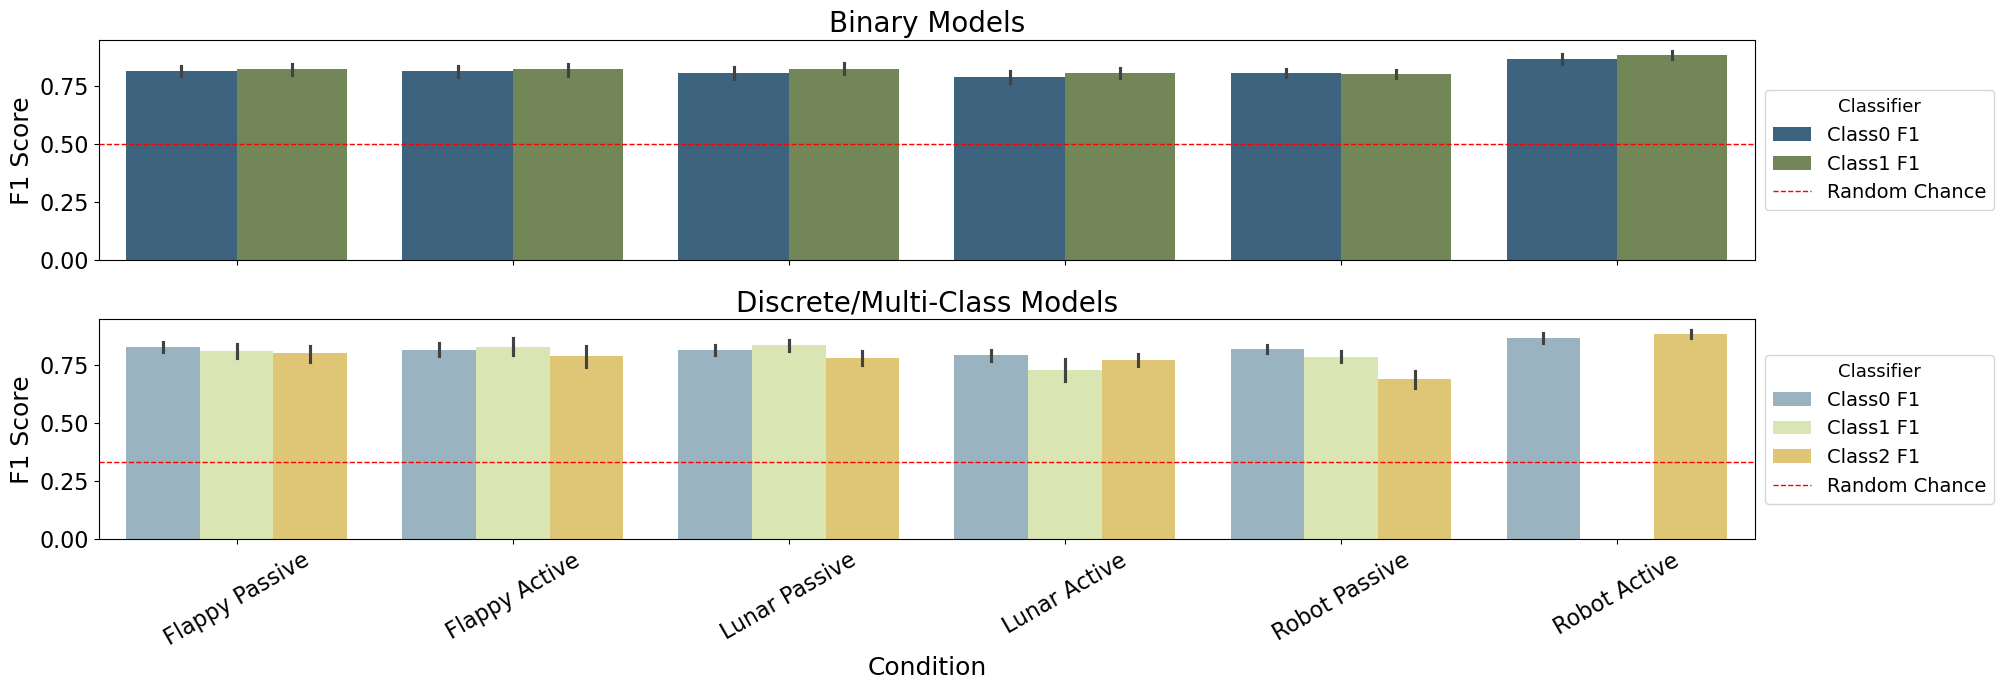

In [11]:
# Filter the data
df_binary = df_singleSubject_binary[(df_singleSubject_binary["TestParticipants"] == df_singleSubject_binary["TrainParticipants"]) & (df_singleSubject_binary["TestConditions"].apply(lambda x: x[0]) == df_singleSubject_binary["TrainConditions"].apply(lambda x: x[0]))]
df_discrete = df_singleSubject_discrete[(df_singleSubject_discrete["TestParticipants"] == df_singleSubject_discrete["TrainParticipants"]) & (df_singleSubject_discrete["TestConditions"].apply(lambda x: x[0]) == df_singleSubject_discrete["TrainConditions"].apply(lambda x: x[0]))]

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Class0 F1', 'Class1 F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Class0 F1', 'Class1 F1', 'Class2 F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Metric', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Models', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=30, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Metric', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete/Multi-Class Models', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=30, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


In [12]:
df_singleSubject_binary["TrainParticipants"] = df_singleSubject_binary["TrainParticipants"].apply(lambda x: x[0] if isinstance(x, list) else x)
df_singleSubject_binary["TestParticipants"] = df_singleSubject_binary["TestParticipants"].apply(lambda x: x[0] if isinstance(x, list) else x)

df_singleSubject_discrete["TrainParticipants"] = df_singleSubject_discrete["TrainParticipants"].apply(lambda x: x[0] if isinstance(x, list) else x)
df_singleSubject_discrete["TestParticipants"] = df_singleSubject_discrete["TestParticipants"].apply(lambda x: x[0] if isinstance(x, list) else x)
df_singleSubject_discrete.head(1)

,Unnamed: 0,Classifier,Accuracy,Precision,Recall,F1,Class0 Recall,Class1 Recall,Class2 Recall,Class0 Precision,...,Macro Recall,Macro Precision,TrainParticipants,TestParticipants,TrainConditions,TestConditions,Experiment,Conditions,Game,Task
0,0,SVM,0.801724,0.803983,0.801724,0.801355,0.758621,NaN,0.844828,0.830189,...,0.801724,0.803983,8,8,[FW],[FW],3,Flappy Passive,Flappy,Passive


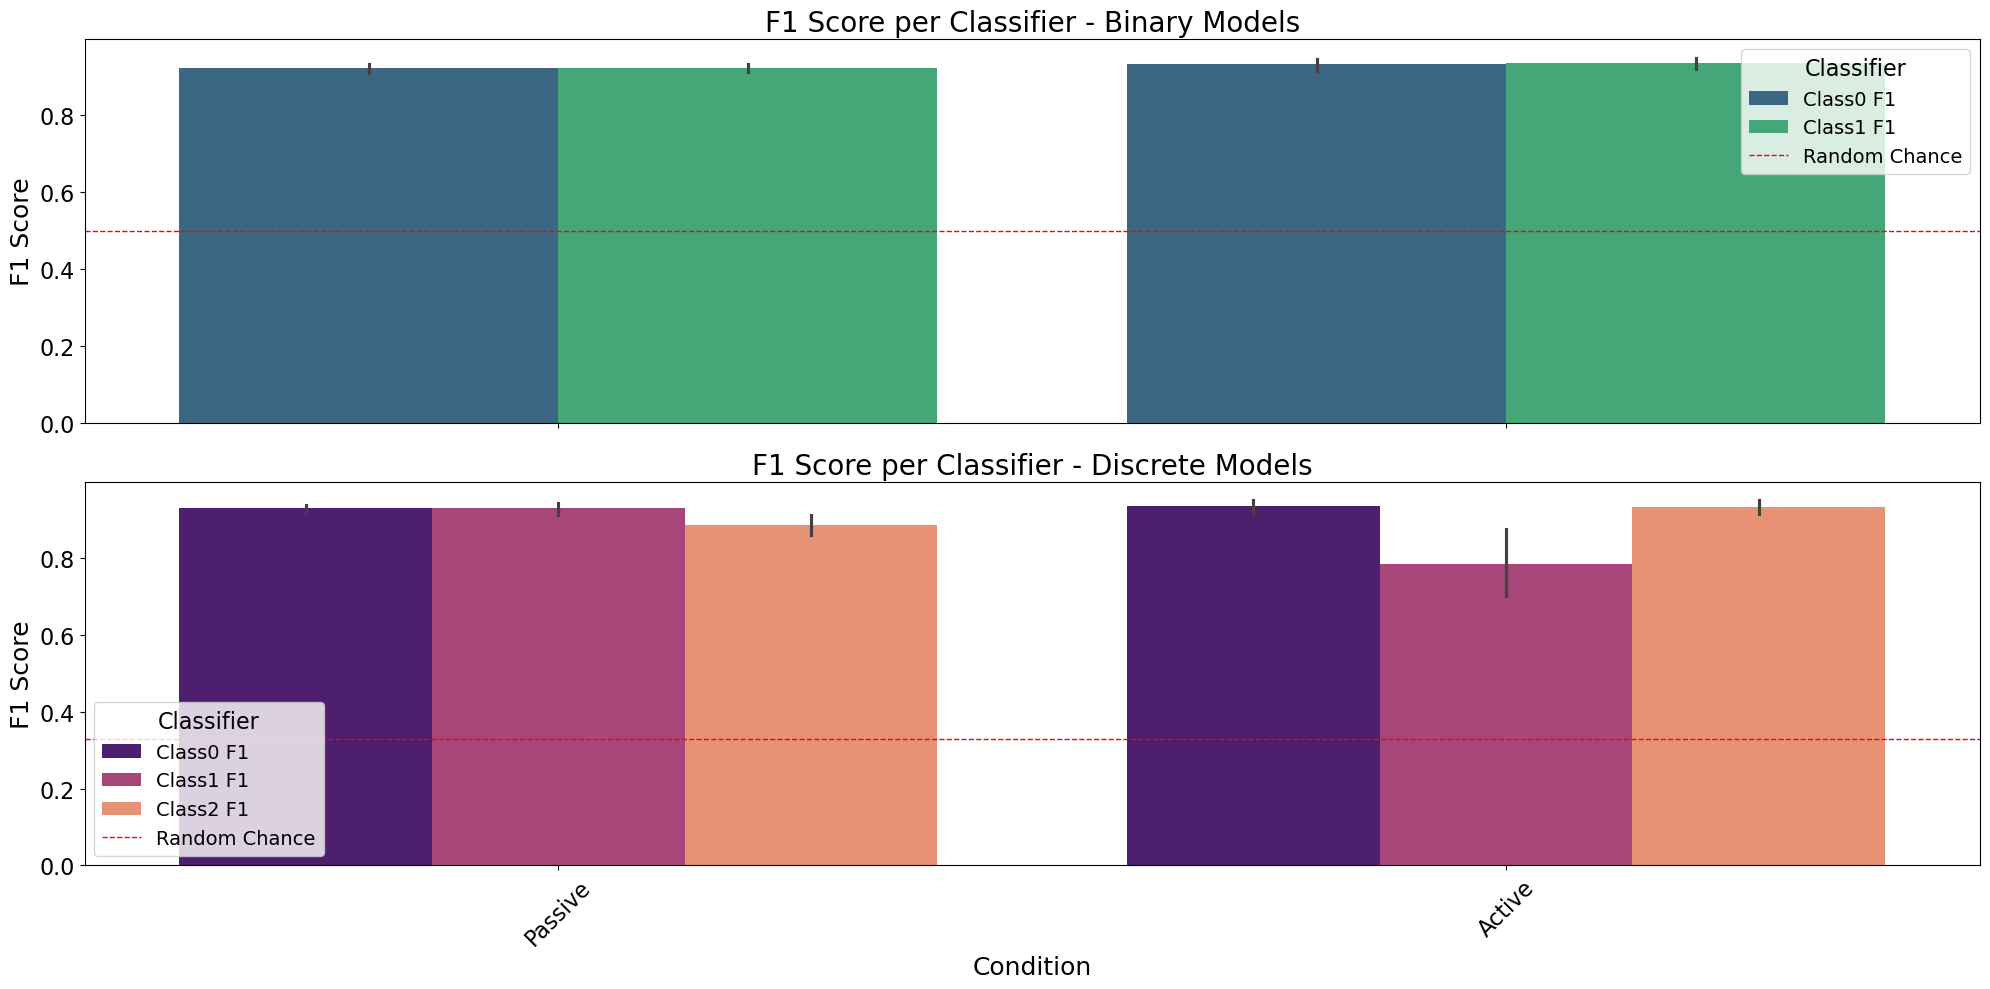

In [13]:
# Filter the data
df_binary = df_singleSubject_binary[
    (df_singleSubject_binary['TestParticipants'] == df_singleSubject_binary["TrainParticipants"]) & 
    (df_singleSubject_binary['TestConditions'] == df_singleSubject_binary["TrainConditions"])
]
df_discrete = df_singleSubject_discrete[
    (df_singleSubject_discrete['TestParticipants'] == df_singleSubject_discrete["TrainParticipants"]) & 
    (df_singleSubject_discrete['TestConditions'] == df_singleSubject_discrete["TrainConditions"])
]

df_binary = df_binary[df_binary['Classifier'] == 'RandomForest']
df_discrete = df_discrete[df_discrete['Classifier'] == 'RandomForest']
# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Task', 'Classifier', 'TrainParticipants'], value_vars=['Class0 F1', 'Class1 F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Task', 'Classifier', 'TrainParticipants'], value_vars=['Class0 F1', 'Class1 F1', 'Class2 F1'], 
                           var_name='Metric', value_name='F1 Score')

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
# Add numbers to the barplot
# Plot for binary data
sns.barplot(data=df_long_binary, x='Task', y='F1 Score', hue='Metric', palette='viridis', ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('F1 Score per Classifier - Binary Models', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=45, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Classifier', title_fontsize='16', fontsize='14')

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Task', y='F1 Score', hue='Metric', palette='magma', ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('F1 Score per Classifier - Discrete Models', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=45, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Classifier', title_fontsize='16', fontsize='14')

plt.tight_layout()
plt.show()

In [14]:
# Get unique participants
df_singleSubject_binary = df_singleSubject_binary[(df_singleSubject_binary["TrainConditions"] == df_singleSubject_binary["TestConditions"]) & (df_singleSubject_binary["TrainParticipants"] == df_singleSubject_binary["TestParticipants"])]
unique_train_participants = set(participant for sublist in df_singleSubject_binary['TrainParticipants'] for participant in sublist)

# Create a DataFrame to store the average F1 scores for each participant
avg_f1_scores = pd.DataFrame(columns=['Participant', 'Average F1 Score'])

palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c", "#93b5c6", "#b4c187", "#f0cf65", "#d7816a", "#bd4f6c"]
# Calculate the average F1 score for each participant
for participant in unique_train_participants:
    df_participant = df_singleSubject_binary[
        (df_singleSubject_binary['TrainParticipants'].apply(lambda x: participant in x)) & 
        (df_singleSubject_binary['Classifier'] == 'MLP')
    ]
    avg_f1_score = df_participant['Macro F1'].mean()
    avg_f1_scores = pd.concat([avg_f1_scores, pd.DataFrame([{'Participant': participant, 'Average F1 Score': avg_f1_score}])], ignore_index=True)

# Plot the average F1 scores for each participant
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=avg_f1_scores, x='Participant', y='Average F1 Score', palette=palette, ax=ax)

# Add a random chance line at 0.5
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')

# Customize the plot
ax.set_title('Average F1 Scores per Participant', fontsize=16)
ax.set_xlabel('Participant', fontsize=14)
ax.set_ylabel('F1 Score', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

TypeError: 'int' object is not iterable

### Classes per Condition using MLP


In [ ]:
# Filter the data
df_binary = df_multiSubject_binary[df_multiSubject_binary['TestParticipants'] == df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_multiSubject_discrete[df_multiSubject_discrete['TestParticipants'] == df_multiSubject_discrete["TrainParticipants"]]

df_binary = df_binary[df_binary['Classifier'] == 'SVM']
df_discrete = df_discrete[df_discrete['Classifier'] == 'SVM']

# Remove "Robot Active" from the discrete data
df_discrete = df_discrete[df_discrete['Conditions'] != 'Robot Active']

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions'], value_vars=['Class0 F1', 'Class1 F1', 'Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions'], value_vars=['Class0 F1', 'Class1 F1', 'Class2 F1', 'Macro F1'], 
                           var_name='Metric', value_name='F1 Score')

palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Map the metric names to desired labels
metric_labels_binary = {'Class0 F1': 'Class 0', 'Class1 F1': 'Class 1', 'Macro F1': 'Macro F1'}
metric_labels_discrete = {'Class0 F1': 'Class 0', 'Class1 F1': 'Class 1', 'Class2 F1': 'Class 2', 'Macro F1': 'Macro F1'}

df_long_binary['Metric'] = df_long_binary['Metric'].map(metric_labels_binary)
df_long_discrete['Metric'] = df_long_discrete['Metric'].map(metric_labels_discrete)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(25, 10), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Metric', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('F1 Scores per Class - Binary Model', fontsize=35)
axes[0].set_xlabel('Condition', fontsize=30)
axes[0].set_ylabel('F1 Score', fontsize=30)
axes[0].tick_params(axis='x', rotation=20, labelsize=28)
axes[0].tick_params(axis='y', labelsize=28)
axes[0].legend(title='Metric', title_fontsize='28', fontsize='24', loc="center left", bbox_to_anchor=(1, 0.5))

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Metric', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('F1 Scores per Class - Discrete Model', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Metric', title_fontsize='28', fontsize='24', loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [ ]:
# Filter the data
df_binary = df_multiSubject_binary[df_multiSubject_binary['TestParticipants'] == df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_multiSubject_discrete[df_multiSubject_discrete['TestParticipants'] == df_multiSubject_discrete["TrainParticipants"]]

# df_binary = df_binary[df_binary['Classifier'] == 'SVM']
# df_discrete = df_discrete[df_discrete['Classifier'] == 'SVM']

# Melt the dataframes
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Classifier', 'Conditions'], value_vars=['Class0 F1', 'Class1 F1', 'Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Classifier', 'Conditions'], value_vars=['Class0 F1', 'Class1 F1', 'Class2 F1', 'Macro F1'], 
                           var_name='Metric', value_name='F1 Score')

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_binary, x='Classifier', y='F1 Score', hue='Conditions', palette='viridis', ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('F1 Scores per Condition and Classifier (Binary)', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=45, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Classifier', title_fontsize='16', fontsize='14')

# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Classifier', y='F1 Score', hue='Conditions', palette='magma', ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('F1 Scores per Condition and Classifier (Discrete)', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=45, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Classifier', title_fontsize='16', fontsize='14')

plt.tight_layout()
plt.show()

In [ ]:
# Filter the data
df_binary = df_multiSubject_binary[df_multiSubject_binary['TestParticipants'] != df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_multiSubject_discrete[df_multiSubject_discrete['TestParticipants'] != df_multiSubject_discrete["TrainParticipants"]]
df_fine_binary = df_finetuning_binary[df_finetuning_binary['TestParticipants'] != df_finetuning_binary["TrainParticipants"]]
df_fine_discrete = df_finetuning_discrete[df_finetuning_discrete['TestParticipants'] != df_finetuning_discrete["TrainParticipants"]]

df_binary_same = df_multiSubject_binary[df_multiSubject_binary['TestParticipants'] == df_multiSubject_binary["TrainParticipants"]]
df_discrete_same = df_multiSubject_discrete[df_multiSubject_discrete['TestParticipants'] == df_multiSubject_discrete["TrainParticipants"]]

# Filter the data for MLP classifier
df_binary_mlp = df_binary[df_binary['Classifier'] == 'MLP']
df_discrete_mlp = df_discrete[df_discrete['Classifier'] == 'MLP']
df_finetuning_binary_mlp = df_fine_binary[df_fine_binary['Classifier'] == 'MLP']
df_finetuning_discrete_mlp = df_fine_discrete[df_fine_discrete['Classifier'] == 'MLP']
df_singleSubject_binary_mlp = df_singleSubject_binary[df_singleSubject_binary['Classifier'] == 'MLP']
df_singleSubject_discrete_mlp = df_singleSubject_discrete[df_singleSubject_discrete['Classifier'] == 'MLP']

# Add a column to distinguish between multisubject, finetuning, and single subject data
df_binary_mlp['ExperimentType'] = 'Multisubject Cross-Validation'
df_discrete_mlp['ExperimentType'] = 'Multisubject Cross-Validation'
df_finetuning_binary_mlp['ExperimentType'] = 'Finetuning'
df_finetuning_discrete_mlp['ExperimentType'] = 'Finetuning'
df_binary_same['ExperimentType'] = 'Multisubject'
df_discrete_same['ExperimentType'] = 'Multisubject'
df_singleSubject_binary_mlp['ExperimentType'] = 'Single Subject'
df_singleSubject_discrete_mlp['ExperimentType'] = 'Single Subject'

# Combine the dataframes
df_combined_binary = pd.concat([df_binary_mlp, df_finetuning_binary_mlp, df_binary_same, df_singleSubject_binary_mlp])
df_combined_discrete = pd.concat([df_discrete_mlp, df_finetuning_discrete_mlp, df_discrete_same, df_singleSubject_discrete_mlp])

# Melt the dataframes
df_long_combined_binary = pd.melt(df_combined_binary.reset_index(), id_vars=['Task', 'Game', 'Conditions', 'ExperimentType'], value_vars=['Macro F1'], 
                                  var_name='Metric', value_name='F1 Score')
df_long_combined_discrete = pd.melt(df_combined_discrete.reset_index(), id_vars=['Task', 'Game', 'Conditions', 'ExperimentType'], value_vars=['Macro F1'], 
                                    var_name='Metric', value_name='F1 Score')

palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Plot for binary data
sns.barplot(data=df_long_combined_binary, x='Game', y='F1 Score', hue='ExperimentType', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('F1 Scores per MultiSubject Experiment - Binary Model', fontsize=24)
axes[0].set_xlabel('Condition', fontsize=20)
axes[0].set_ylabel('F1 Score', fontsize=20)
axes[0].tick_params(axis='x', rotation=45, labelsize=18)
axes[0].tick_params(axis='y', labelsize=18)
axes[0].legend(title='Experiment Type', title_fontsize='18', fontsize='16')

# Plot for discrete data
sns.barplot(data=df_long_combined_discrete, x='Game', y='F1 Score', hue='ExperimentType', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('F1 Scores per MultiSubject Experiment - Discrete Model', fontsize=24)
axes[1].set_xlabel('Condition', fontsize=20)
axes[1].set_ylabel('F1 Score', fontsize=20)
axes[1].tick_params(axis='x', rotation=45, labelsize=18)
axes[1].tick_params(axis='y', labelsize=18)
axes[1].legend(title='Experiment Type', title_fontsize='18', fontsize='16')

plt.tight_layout()
plt.show()